# Importação de Bibliotecas

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

# Extração de Dados

In [ ]:
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# Normalização da Estrutura do JSON

In [ ]:
df = pd.json_normalize(df.to_dict(orient="records"))

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# Tratamentos Iniciais

In [ ]:
df.columns = df.columns.str.replace(".", "_")

df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# Verificação de Inconsistências

In [ ]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


# Tratamento da Variável Alvo (Churn)

In [ ]:
df['Churn'] = df['Churn'].replace({
    'Yes': 1,
    'No': 0
})

# Conversão de Variáveis Numéricas

In [ ]:
df['account_Charges_Total'] = pd.to_numeric(
    df['account_Charges_Total'],
    errors='coerce'
)

# Remoção de Valores Nulos

In [ ]:
df = df.dropna()

# Remoção de Colunas Irrelevantes

In [ ]:
df = df.drop(columns=['customerID'])

# Encoding de Variáveis Categóricas

In [ ]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,Churn_1,Churn_,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0,9,65.6,593.30,False,False,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,False,False,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,True,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,True,False,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,True,False,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


# Verificação de Proporção de Evasão

In [ ]:
frequencia = df['Churn_1'].value_counts()
proporcao = df['Churn_1'].value_counts(normalize=True) * 100

print("Frequência:")
print(frequencia)

print("\nProporção (%):")
print(proporcao.round(2))

Frequência:
Churn_1
False    5387
True     1869
Name: count, dtype: int64

Proporção (%):
Churn_1
False    74.24
True     25.76
Name: proportion, dtype: float64


**Visualização**

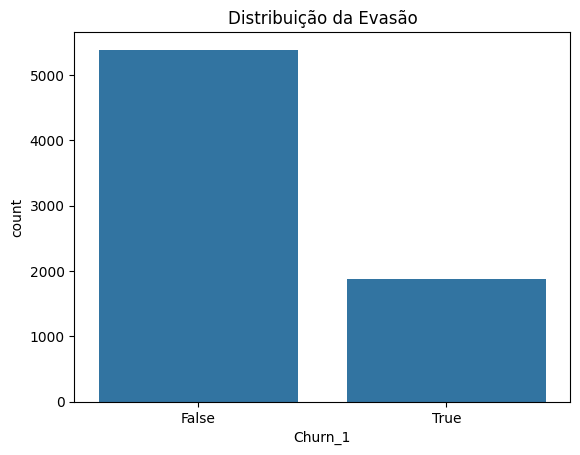

In [ ]:
sns.countplot(x='Churn_1', data=df)
plt.title("Distribuição da Evasão")
plt.show()

# Análise de Correlação

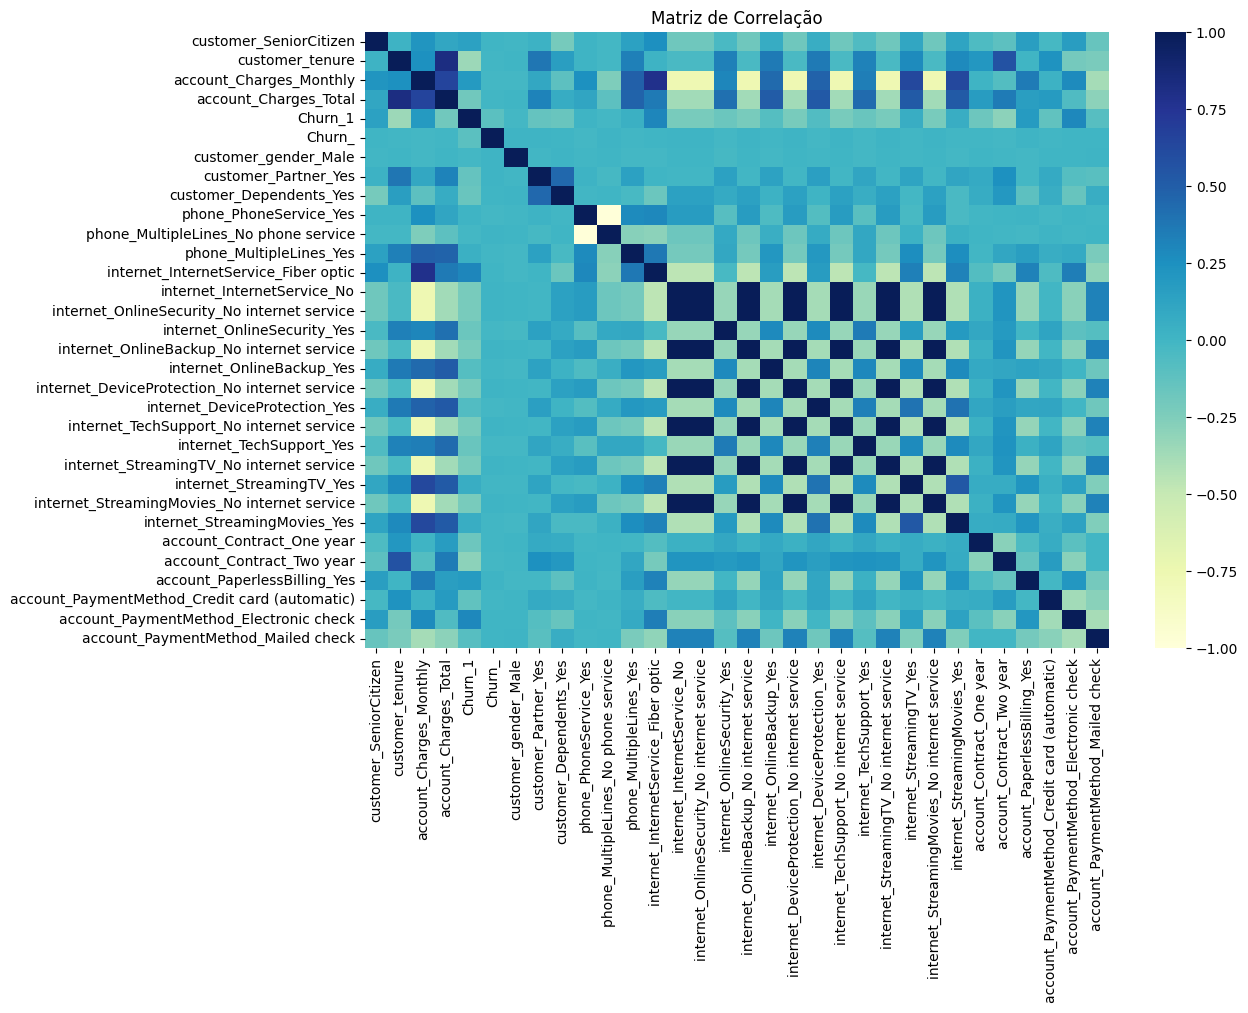

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="YlGnBu",
    center=0
)

plt.title("Matriz de Correlação")
plt.show()

# Separação Entre Variáveis Preditoras e Alvo

In [ ]:
X = df.drop('Churn_1', axis=1)
y = df['Churn_1']

# Balanceamento de Classes


In [ ]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X, y)

print("Distribuição após SMOTE:")

print(pd.Series(y_res).value_counts())

Distribuição após SMOTE:
Churn_1
False    5387
True     5387
Name: count, dtype: int64


# Separação Treino e Teste

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res,
    y_res,
    test_size=0.2,
    random_state=42,
    stratify=y_res
)

# Normalização de Dados

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelos de Machine Learning

Após o tratamento, encoding e análise de correlação, os dados foram preparados para o treinamento de modelos de Machine Learning. Foram selecionados dois algoritmos de classificação amplamente utilizados para problemas de churn: Regressão Logística e Random Forest.

**Modelo 1 — Regressão Logística**

In [ ]:
modelo_log = LogisticRegression(max_iter=200)

modelo_log.fit(X_train_scaled, y_train)

y_pred_log = modelo_log.predict(X_test_scaled)

**Modelo 2 — Random Forest**

In [ ]:
modelo_rf = RandomForestClassifier(random_state=42)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

# Avaliação dos Modelos

**Função para gerar métricas**

In [ ]:
def avaliar_modelo(nome, y_test, y_pred):

    return {
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    }

**Comparação**

In [ ]:
resultados = [

    avaliar_modelo("Regressão Logística", y_test, y_pred_log),
    avaliar_modelo("Random Forest", y_test, y_pred_rf)

]

df_resultados = pd.DataFrame(resultados)

df_resultados

,Modelo,Acurácia,Precisão,Recall,F1-score
0,Regressão Logística,0.842227,0.835305,0.852368,0.843750
1,Random Forest,0.860789,0.850316,0.875580,0.862763


# Matriz de Confusão

In [ ]:
print("Regressão Logística")

print(confusion_matrix(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

Regressão Logística
[[897 181]
 [159 918]]
              precision    recall  f1-score   support

       False       0.85      0.83      0.84      1078
        True       0.84      0.85      0.84      1077

    accuracy                           0.84      2155
   macro avg       0.84      0.84      0.84      2155
weighted avg       0.84      0.84      0.84      2155



# Importância das Variáveis

Random Forest permite avaliar importância.

In [ ]:
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importancias.head(10)

,0
account_Charges_Total,0.169697
customer_tenure,0.150734
account_Charges_Monthly,0.129735
account_PaymentMethod_Electronic check,0.093163
internet_InternetService_Fiber optic,0.052345
account_PaperlessBilling_Yes,0.043557
account_Contract_Two year,0.041284
account_Contract_One year,0.023434
customer_gender_Male,0.023324
phone_MultipleLines_Yes,0.022491


**Visualização**

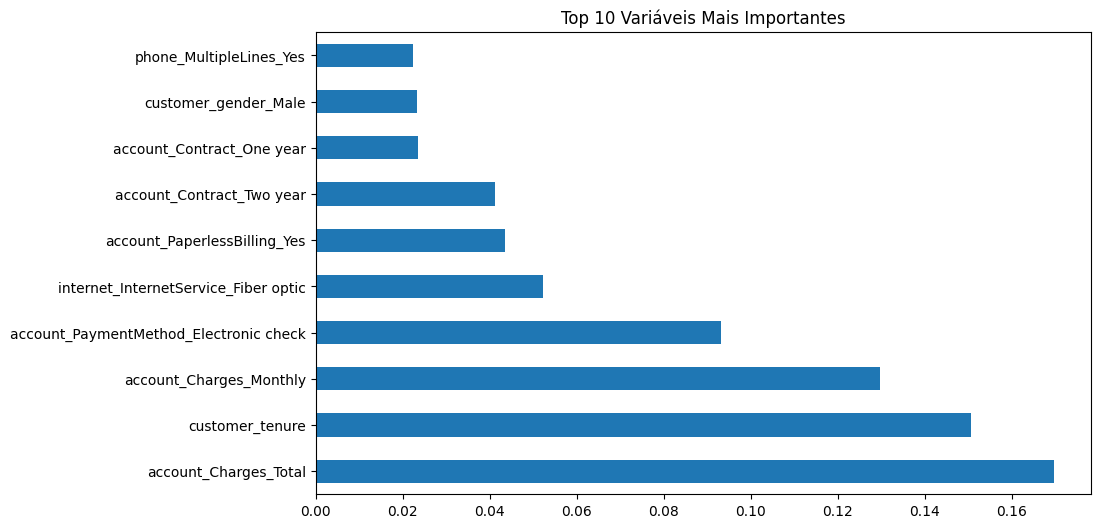

In [ ]:
plt.figure(figsize=(10,6))

importancias.head(10).plot(kind="barh")

plt.title("Top 10 Variáveis Mais Importantes")

plt.show()

In [ ]:
probabilidades = modelo_rf.predict_proba(X_test)

df_resultado = pd.DataFrame({
    'Real': y_test,
    'Probabilidade_Churn': probabilidades[:,1]
})

df_resultado.head()

,Real,Probabilidade_Churn
512,True,0.14
4893,True,0.96
4179,False,0.11
2027,True,0.66
1035,False,0.12


# Previsão de Probabilidade de Churn

In [ ]:
probabilidades = modelo_rf.predict_proba(X_test)

df_resultado = pd.DataFrame({
    'Real': y_test,
    'Probabilidade_Churn': probabilidades[:,1]
})

df_resultado.head()

,Real,Probabilidade_Churn
512,True,0.14
4893,True,0.96
4179,False,0.11
2027,True,0.66
1035,False,0.12


# Clientes com Maior Probabilidade de Churn

In [ ]:
df_resultado.sort_values(by='Probabilidade_Churn', ascending=False).head(10)

,Real,Probabilidade_Churn
10247,True,1.0
10251,True,1.0
9040,True,1.0
10413,True,1.0
10087,True,1.0
10102,True,1.0
7957,True,1.0
10446,True,1.0
7915,True,1.0
7467,True,1.0


# Interpretação

O modelo gera uma probabilidade de evasão para cada cliente.

* Valores próximos de 1 indicam alto risco de churn

* Valores próximos de 0 indicam baixo risco de churn

**Exemplo:**

* Cliente 4893 → probabilidade 0.96
→ cliente com altíssimo risco de cancelamento

* Cliente 2027 → probabilidade 0.66
→ cliente com risco moderado a alto

* Cliente 1035 → probabilidade 0.12
→ cliente com baixo risco de evasão

# Aplicação Estratégica para a Empresa

Esse tipo de previsão permite que a Telecom X identifique clientes com maior risco de cancelamento antes que a evasão aconteça.

Com essas informações, a empresa pode implementar ações como:

* campanhas de retenção direcionadas

* ofertas personalizadas para clientes de alto risco

* melhorias nos serviços mais associados à evasão

Dessa forma, a empresa pode atuar de forma preventiva, reduzindo perdas financeiras e aumentando a fidelização de clientes.